In [1]:
import time
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from dolcestat.neighbors import KNNClassifier, KNNRegressor
from dolcestat.preprocessing import DolceSet

METRICS  = ["euclidean", "manhattan", "minkowski"]
WEIGHTS  = ["uniform", "distance", "squared_distance", "gaussian"]
K_VALUES = list(range(1, 21))

## Regression

Synthetic dataset: 1 000 samples, 20 features, Gaussian noise. Target is standardized so all flavours are numerically comparable.

We compare three **distance metrics** (`euclidean`, `manhattan`, `minkowski p=3`) and four **weighting schemes** (`uniform`, `distance`, `squared_distance`, `gaussian`) against `sklearn.KNeighborsRegressor` as a baseline.

In [2]:
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, noise=15, random_state=42)
y_reg = (y_reg - y_reg.mean()) / y_reg.std()

feature_names = [f"x{i}" for i in range(X_reg.shape[1])]
df_reg = pl.DataFrame({name: X_reg[:, i] for i, name in enumerate(feature_names)})
df_reg = df_reg.with_columns(pl.Series("target", y_reg))

np.random.seed(42)
n = len(df_reg)
idx = np.random.permutation(n)
train_idx, test_idx = idx[: int(n * 0.8)], idx[int(n * 0.8) :]

ds_reg_train = DolceSet()
ds_reg_train.load_from_polars_dataframe(df_reg[train_idx.tolist()], target_col="target")
ds_reg_train.scale("standardize")

ds_reg_test = DolceSet()
ds_reg_test.load_from_polars_dataframe(df_reg[test_idx.tolist()], target_col="target")
train_stats = ds_reg_train.scaling_info["details"][0]["stats"]
ds_reg_test.scale("standardize", mean=train_stats["mean"], std=train_stats["std"])

print(f"Train: {ds_reg_train.X.shape}  |  Test: {ds_reg_test.X.shape}")
df_reg.head(3)

Train: (800, 20)  |  Test: (200, 20)


x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,target
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.225842,1.551378,-0.107347,0.859695,-0.942963,-1.096625,-1.197167,-1.733767,-0.950042,1.27406,1.67299,1.477373,0.335126,-0.621135,-1.525106,1.011097,1.478184,-1.351547,0.364602,0.133166,0.110231
0.110836,-1.454615,0.263888,-1.65451,0.818549,0.482849,0.358334,-0.061366,0.327626,1.270846,-2.128649,-0.546838,2.679629,-1.851587,0.87209,-0.987858,1.744496,-1.426464,-0.604514,-0.166242,-1.2742
0.4586,-0.08128,-0.698474,0.737528,0.860085,0.275249,0.333945,-1.076817,0.947821,-0.181406,-0.379908,0.37961,1.508083,0.55538,-1.383018,-0.836187,0.60673,0.908223,0.511415,-2.093178,0.935509


In [3]:
knn_reg = KNNRegressor(ds_reg_train)

sk_reg = KNeighborsRegressor(n_neighbors=5, metric="euclidean")
sk_reg.fit(ds_reg_train.X, ds_reg_train.y)
sk_mae = np.mean(np.abs(sk_reg.predict(ds_reg_test.X) - ds_reg_test.y))

print(f"{'metric':<18} | {'MAE':>8}")
print("-" * 30)
for metric in METRICS:
    p = 3 if metric == "minkowski" else None
    pred = knn_reg.predict(ds_reg_test, k=5, metric=metric, minkowski_p=p)
    mae = np.mean(np.abs(pred - ds_reg_test.y))
    label = f"{metric} (p=3)" if p else metric
    print(f"{label:<18} | {mae:8.4f}")
print(f"{'sklearn':.<18} | {sk_mae:8.4f}")

metric             |      MAE
------------------------------
euclidean          |   0.4683
manhattan          |   0.5026
minkowski (p=3)    |   0.4804
sklearn........... |   0.4683


In [4]:
print(f"{'weights':<18} | {'MAE':>8}")
print("-" * 30)
for w in WEIGHTS:
    pred = knn_reg.predict(ds_reg_test, k=5, weights=w)
    mae = np.mean(np.abs(pred - ds_reg_test.y))
    print(f"{w:<18} | {mae:8.4f}")

weights            |      MAE
------------------------------
uniform            |   0.4683
distance           |   0.4650
squared_distance   |   0.4617
gaussian           |   0.5839


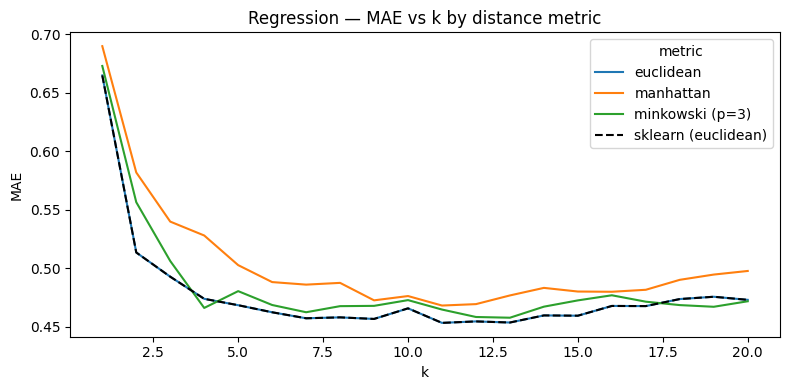

In [5]:
# MAE vs k, one line per distance metric
metric_maes = {m: [] for m in METRICS}
for k in K_VALUES:
    for metric in METRICS:
        p = 3 if metric == "minkowski" else None
        pred = knn_reg.predict(ds_reg_test, k=k, metric=metric, minkowski_p=p)
        metric_maes[metric].append(np.mean(np.abs(pred - ds_reg_test.y)))

sk_reg_all = KNeighborsRegressor(metric="euclidean")
sk_reg_all.fit(ds_reg_train.X, ds_reg_train.y)
sk_maes = [
    np.mean(np.abs(sk_reg_all.set_params(n_neighbors=k).predict(ds_reg_test.X) - ds_reg_test.y))
    for k in K_VALUES
]

fig, ax = plt.subplots(figsize=(8, 4))
for metric, maes in metric_maes.items():
    label = f"{metric} (p=3)" if metric == "minkowski" else metric
    ax.plot(K_VALUES, maes, label=label)
ax.plot(K_VALUES, sk_maes, "k--", label="sklearn (euclidean)")
ax.set_xlabel("k")
ax.set_ylabel("MAE")
ax.set_title("Regression — MAE vs k by distance metric")
ax.legend(title="metric")
plt.tight_layout()
plt.show()

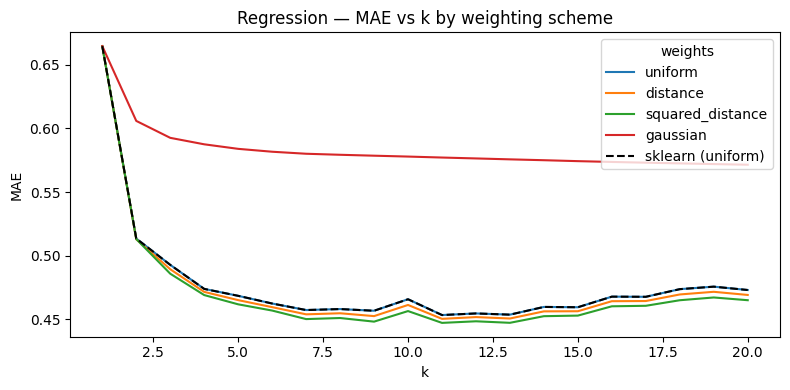

In [6]:
# MAE vs k, one line per weighting scheme
weight_maes = {w: [] for w in WEIGHTS}
for k in K_VALUES:
    for w in WEIGHTS:
        pred = knn_reg.predict(ds_reg_test, k=k, weights=w)
        weight_maes[w].append(np.mean(np.abs(pred - ds_reg_test.y)))

fig, ax = plt.subplots(figsize=(8, 4))
for w, maes in weight_maes.items():
    ax.plot(K_VALUES, maes, label=w)
ax.plot(K_VALUES, sk_maes, "k--", label="sklearn (uniform)")
ax.set_xlabel("k")
ax.set_ylabel("MAE")
ax.set_title("Regression — MAE vs k by weighting scheme")
ax.legend(title="weights")
plt.tight_layout()
plt.show()

## Binary Classification

Synthetic dataset: 1 000 samples, 20 features (10 informative), balanced classes.  
Target is stored as strings (`"class_0"` / `"class_1"`) to exercise `KNNClassifier`'s string-label path.  
Metric is **accuracy**. Baseline: `sklearn.KNeighborsClassifier`.

In [7]:
X_clf, y_clf = make_classification(
    n_samples=1000, n_features=20, n_informative=10, random_state=42
)
y_clf_str = np.where(y_clf == 0, "class_0", "class_1")

df_clf = pl.DataFrame({name: X_clf[:, i] for i, name in enumerate(feature_names)})
df_clf = df_clf.with_columns(pl.Series("target", y_clf_str))

np.random.seed(42)
n = len(df_clf)
idx = np.random.permutation(n)
train_idx, test_idx = idx[: int(n * 0.8)], idx[int(n * 0.8) :]

ds_clf_train = DolceSet()
ds_clf_train.load_from_polars_dataframe(df_clf[train_idx.tolist()], target_col="target")
ds_clf_train.scale("standardize")

ds_clf_test = DolceSet()
ds_clf_test.load_from_polars_dataframe(df_clf[test_idx.tolist()], target_col="target")
train_stats_clf = ds_clf_train.scaling_info["details"][0]["stats"]
ds_clf_test.scale("standardize", mean=train_stats_clf["mean"], std=train_stats_clf["std"])

unique, counts = np.unique(ds_clf_train.y, return_counts=True)
print(f"Class distribution (train): {dict(zip(unique.tolist(), counts.tolist()))}")
print(f"Train: {ds_clf_train.X.shape}  |  Test: {ds_clf_test.X.shape}")

Class distribution (train): {'class_0': 398, 'class_1': 402}
Train: (800, 20)  |  Test: (200, 20)


In [8]:
knn_clf = KNNClassifier(ds_clf_train)

sk_clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
sk_clf.fit(ds_clf_train.X, ds_clf_train.y)
sk_acc = np.mean(sk_clf.predict(ds_clf_test.X) == ds_clf_test.y)

print(f"{'metric':<18} | {'accuracy':>10}")
print("-" * 32)
for metric in METRICS:
    p = 3 if metric == "minkowski" else None
    pred = knn_clf.predict(ds_clf_test, k=5, metric=metric, minkowski_p=p)
    acc = np.mean(pred == ds_clf_test.y)
    label = f"{metric} (p=3)" if p else metric
    print(f"{label:<18} | {acc:10.4f}")
print(f"{'sklearn':.<18} | {sk_acc:10.4f}")

metric             |   accuracy
--------------------------------
euclidean          |     0.9100
manhattan          |     0.8900
minkowski (p=3)    |     0.9200
sklearn........... |     0.9100


In [9]:
# Verbose output: class probabilities for first 5 test samples
pred_y, pred_proba = knn_clf.predict(ds_clf_test, k=5, verbose_output=True)
classes = np.unique(ds_clf_train.y)
print(f"Classes: {classes.tolist()}")
print()
for i in range(5):
    print(f"  Predicted: {pred_y[i]}  |  True: {ds_clf_test.y[i]}")
    print(f"  Proba:     {dict(zip(classes, pred_proba[i].round(2)))}")
    print()

print(f"{'weights':<18} | {'accuracy':>10}")
print("-" * 32)
for w in WEIGHTS:
    pred = knn_clf.predict(ds_clf_test, k=5, weights=w)
    acc = np.mean(pred == ds_clf_test.y)
    print(f"{w:<18} | {acc:10.4f}")

Classes: ['class_0', 'class_1']

  Predicted: class_1  |  True: class_1
  Proba:     {'class_0': 0.0, 'class_1': 1.0}

  Predicted: class_1  |  True: class_1
  Proba:     {'class_0': 0.4, 'class_1': 0.6}

  Predicted: class_1  |  True: class_1
  Proba:     {'class_0': 0.0, 'class_1': 1.0}

  Predicted: class_1  |  True: class_1
  Proba:     {'class_0': 0.0, 'class_1': 1.0}

  Predicted: class_0  |  True: class_0
  Proba:     {'class_0': 1.0, 'class_1': 0.0}

weights            |   accuracy
--------------------------------
uniform            |     0.9100
distance           |     0.9100
squared_distance   |     0.9100
gaussian           |     0.8600


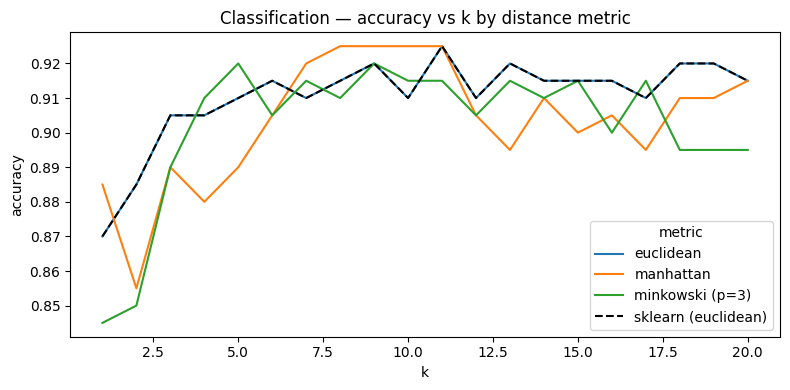

In [10]:
# Accuracy vs k, one line per distance metric
metric_accs = {m: [] for m in METRICS}
for k in K_VALUES:
    for metric in METRICS:
        p = 3 if metric == "minkowski" else None
        pred = knn_clf.predict(ds_clf_test, k=k, metric=metric, minkowski_p=p)
        metric_accs[metric].append(np.mean(pred == ds_clf_test.y))

sk_clf_all = KNeighborsClassifier(metric="euclidean")
sk_clf_all.fit(ds_clf_train.X, ds_clf_train.y)
sk_accs = [
    np.mean(sk_clf_all.set_params(n_neighbors=k).predict(ds_clf_test.X) == ds_clf_test.y)
    for k in K_VALUES
]

fig, ax = plt.subplots(figsize=(8, 4))
for metric, accs in metric_accs.items():
    label = f"{metric} (p=3)" if metric == "minkowski" else metric
    ax.plot(K_VALUES, accs, label=label)
ax.plot(K_VALUES, sk_accs, "k--", label="sklearn (euclidean)")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Classification — accuracy vs k by distance metric")
ax.legend(title="metric")
plt.tight_layout()
plt.show()

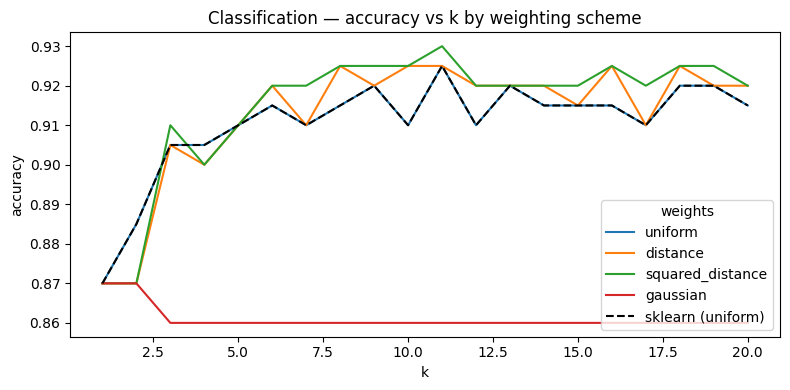

In [11]:
# Accuracy vs k, one line per weighting scheme
weight_accs = {w: [] for w in WEIGHTS}
for k in K_VALUES:
    for w in WEIGHTS:
        pred = knn_clf.predict(ds_clf_test, k=k, weights=w)
        weight_accs[w].append(np.mean(pred == ds_clf_test.y))

fig, ax = plt.subplots(figsize=(8, 4))
for w, accs in weight_accs.items():
    ax.plot(K_VALUES, accs, label=w)
ax.plot(K_VALUES, sk_accs, "k--", label="sklearn (uniform)")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Classification — accuracy vs k by weighting scheme")
ax.legend(title="weights")
plt.tight_layout()
plt.show()

## Predict time — dolcestat vs sklearn

dolcestat's KNN computes the full distance matrix in pure Python/NumPy; sklearn uses a KD-tree
or ball-tree under the hood. The table below shows wall-clock predict time and MAE at selected
values of k for the regression task.

In [12]:
def timed_predict(model, data, k, **kwargs):
    t0 = time.perf_counter()
    pred = model.predict(data, k=k, **kwargs)
    return time.perf_counter() - t0, pred

sk_reg_timed = KNeighborsRegressor(metric="euclidean")
sk_reg_timed.fit(ds_reg_train.X, ds_reg_train.y)

print(f"{'k':>4} | {'dolcestat (s)':>14} | {'sklearn (s)':>12} | {'MAE (dolcestat)':>16} | {'MAE (sklearn)':>14}")
print("-" * 70)
for k in [1, 3, 5, 10, 15, 20]:
    t_dc, pred_dc = timed_predict(knn_reg, ds_reg_test, k=k)
    sk_reg_timed.set_params(n_neighbors=k)
    t0 = time.perf_counter()
    pred_sk = sk_reg_timed.predict(ds_reg_test.X)
    t_sk = time.perf_counter() - t0
    mae_dc = np.mean(np.abs(pred_dc - ds_reg_test.y))
    mae_sk = np.mean(np.abs(pred_sk - ds_reg_test.y))
    print(f"{k:>4} | {t_dc:14.4f} | {t_sk:12.4f} | {mae_dc:16.4f} | {mae_sk:14.4f}")

   k |  dolcestat (s) |  sklearn (s) |  MAE (dolcestat) |  MAE (sklearn)
----------------------------------------------------------------------
   1 |         0.3673 |       0.0017 |           0.6647 |         0.6647
   3 |         0.3784 |       0.0011 |           0.4927 |         0.4927
   5 |         0.3672 |       0.0014 |           0.4683 |         0.4683
  10 |         0.3672 |       0.0012 |           0.4657 |         0.4657
  15 |         0.3639 |       0.0014 |           0.4594 |         0.4594
  20 |         0.3651 |       0.0016 |           0.4729 |         0.4729


## Summary

In [13]:
# Best metric and best weight at k=5 for each task
best_metric_reg  = min(METRICS, key=lambda m: metric_maes[m][4])   # index 4 = k=5
best_weight_reg  = min(WEIGHTS, key=lambda w: weight_maes[w][4])
best_k_reg       = K_VALUES[np.argmin([weight_maes["uniform"][i] for i in range(len(K_VALUES))])]

best_metric_clf  = max(METRICS, key=lambda m: metric_accs[m][4])
best_weight_clf  = max(WEIGHTS, key=lambda w: weight_accs[w][4])
best_k_clf       = K_VALUES[np.argmax([weight_accs["uniform"][i] for i in range(len(K_VALUES))])]

summary = pl.DataFrame([
    {"task": "Regression",     "best_metric": best_metric_reg, "best_weights": best_weight_reg, "best_k (uniform)": best_k_reg},
    {"task": "Classification", "best_metric": best_metric_clf, "best_weights": best_weight_clf, "best_k (uniform)": best_k_clf},
])
print(summary)

shape: (2, 4)
┌────────────────┬─────────────┬──────────────────┬──────────────────┐
│ task           ┆ best_metric ┆ best_weights     ┆ best_k (uniform) │
│ ---            ┆ ---         ┆ ---              ┆ ---              │
│ str            ┆ str         ┆ str              ┆ i64              │
╞════════════════╪═════════════╪══════════════════╪══════════════════╡
│ Regression     ┆ euclidean   ┆ squared_distance ┆ 11               │
│ Classification ┆ minkowski   ┆ uniform          ┆ 11               │
└────────────────┴─────────────┴──────────────────┴──────────────────┘
